### Coding Attention Mechanism

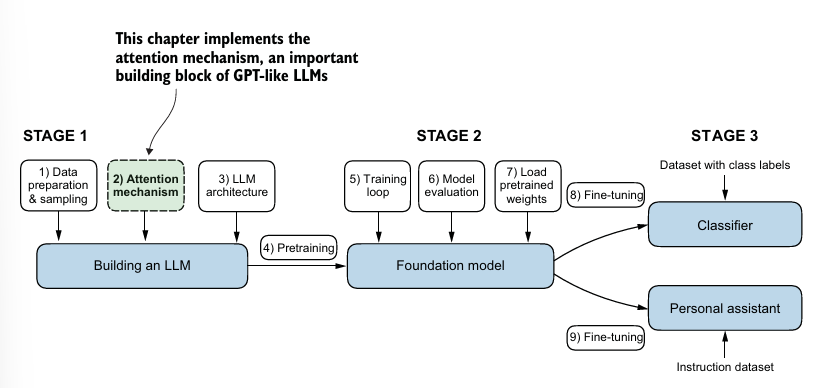

Step 2 of stage 1: Implementing attention mechanisms. 

There are four types of attention mechanism. 

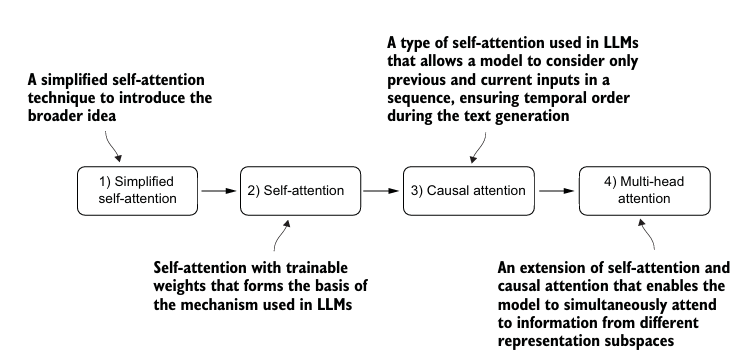

The first step of implementing self-attention is to compute the intermediate values ω,referred to as attention scores

In [1]:
import torch
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your    
   [0.55, 0.87, 0.66], # journey  
   [0.57, 0.85, 0.64], # starts  
   [0.22, 0.58, 0.33], # with    
   [0.77, 0.25, 0.10], # one     
   [0.05, 0.80, 0.55]] # step    
)

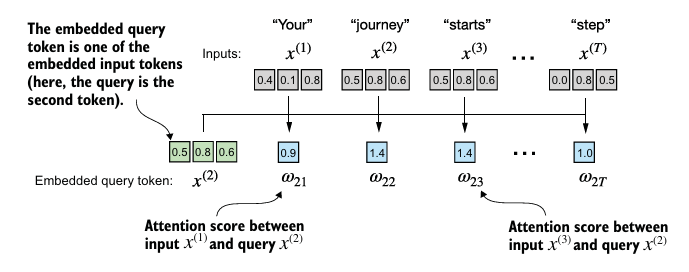

we calculate the intermediate attention scores between the
query token and each input token

In [5]:
torch.empty(inputs.shape[0])

tensor([0., 0., 0., 0., 0., 0.])

In [6]:
query = inputs[1]
attn_score_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_score_2[i] = torch.dot(x_i, query)

print(attn_score_2)


tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


the higher the dot product, the higher the similarity and attention score between two elements.

In [7]:
# normalize each of the attention scores

attn_weights_2_tmp = attn_score_2 / attn_score_2.sum()
print("Attention weights:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


In [8]:
# softmax function for normalizing the attention scores

def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)
attn_weights_2_naive = softmax_naive(attn_score_2)
print("Attention weights:", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


In [9]:
attn_weights_2 = torch.softmax(attn_score_2, dim=0)
print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


Final step, calculating the context vector z(2) by multiplying the
embedded input tokens, x(i), with the corresponding attention weights and then summing the resulting vectors.

In [11]:
# calculate context vector. 

query = inputs[1]
context_vec_2 = torch.zeros(query.shape)
for i , x_i in enumerate(inputs):
    context_vec_2+= attn_weights_2[i]*x_i

print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


In [12]:
# Computing attention weights for all input tokens

attn_scores = torch.empty(6, 6)
for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)
print(attn_scores)


tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [13]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [14]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [16]:
attn_weights.shape

torch.Size([6, 6])

In [17]:
inputs.shape

torch.Size([6, 3])

In [15]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


Next, we will add trainable weights, enabling the LLM to learn from data and improve its per formance on specific tasks.

The self-attention mechanism with trainable weights builds
on the previous concepts: we want to compute context vectors as weighted sums over the input vectors specific to a certain input element.

The most notable difference is the introduction of weight matrices that are
updated during model training

These trainable weight matrices are crucial so that the model (specifically, the attention module inside the model) can learn to produce "good" context vectors.

In [18]:
# Implementing self-attention with trainable weights

x_2 = inputs[1]    
d_in = inputs.shape[1]     
d_out = 2 

In [19]:
#  initialize the three weight matrices Wq, Wk, and Wv 

torch.manual_seed(123)

W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [20]:
torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

Parameter containing:
tensor([[0.3821, 0.6605],
        [0.8536, 0.5932],
        [0.6367, 0.9826]])

In [22]:
query_2 = x_2 @ W_query # [1,3] . [3,2] = [1,2]
key_2 = x_2 @ W_key # [1,3] . [3,2] = [1,2]
value_2 = x_2 @ W_value # [1,3] . [3,2] = [1,2]
print(query_2) #[1,2]

tensor([0.4306, 1.4551])


In [23]:
keys = inputs @ W_key 
values = inputs @ W_value
print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


In [24]:
keys_2 = keys[1]            
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(1.8524)


In [25]:
attn_scores_2 = query_2 @ keys.T      
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [27]:
d_k = keys.shape[-1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


In [ ]:
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


In [29]:
#  compact self-attention class

import torch.nn as nn 

class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        keys = x@self.W_key
        queries = x@self.W_query
        values = x@self.W_value

        attn_scores = queries @ keys.T 
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )

        context_vec = attn_weights @ values

        return context_vec

In [30]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [45]:
sa_v1.W_key

Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]], requires_grad=True)

In [ ]:
#  A self-attention class using PyTorch’s Linear layers

class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias = False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x) # [2,3]
        queries = self.W_query(x) # [2,3]
        values = self.W_value(x) # [2,3]
        attn_scores = queries @ keys.T # [2,3] . [3,2] = [2,2]
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )

        context_vec = attn_weights @ values

        return context_vec


In [32]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


🔗 Exercise 3.1 Comparing SelfAttention_v1 and SelfAttention_v2

In [51]:
class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(sa_v2.W_query.weight.T)
        self.W_key = nn.Parameter(sa_v2.W_key.weight.T)
        self.W_value = nn.Parameter(sa_v2.W_value.weight.T)

    def forward(self, x):
        keys = x@self.W_key
        queries = x@self.W_query
        values = x@self.W_value

        attn_scores = queries @ keys.T 
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )

        context_vec = attn_weights @ values

        return context_vec

In [52]:
sa_v1_v2 = SelfAttention_v1(d_in, d_out)
sa_v1_v2(inputs)

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)

Hiding future words with causal attention/mask attention

- It restricts a model to only consider previous and current inputs in a sequence and  mask out the future tokens

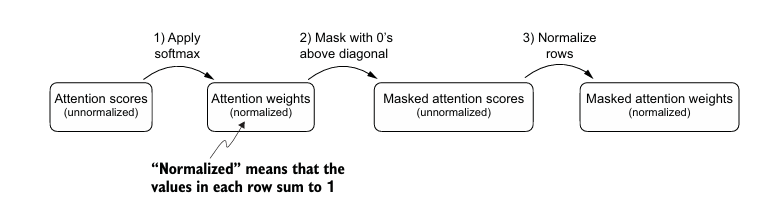

Applying a causal attention mask

1. In the first step, we compute the attention weights using the softmax function

2.  second step using PyTorch’s tril function to create a mask where the values above the diagonal are zero

3. The third step is to renormalize the attention weights to sum up to 1 again in each row. We can achieve this by dividing each element in each row by the sum in each row

In [54]:
# step 1
queries = sa_v2.W_query(inputs)    
keys = sa_v2.W_key(inputs) 
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [55]:
# step 2

context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


multiply this mask with the attention weights to zero-out the values above
the diagonal

In [58]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


In [59]:
# step 3 

row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


After masking and renormalization, the distribution of attention
weights is as if it was calculated only among the unmasked positions to begin with. This ensures there’s no information leakage from future (or otherwise masked) tokens as we intended.

In [61]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


In [62]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [63]:
# Masking additional attention weights with dropout

torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
example = torch.ones(6,6)
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


In [64]:
torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


In [65]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)  

torch.Size([2, 6, 3])


In [66]:
#  Implementing a compact causal attention class

class CausalAttention(nn.Module):

    def __init__(self, d_in, d_out, context_length, 
                 dropout, qkv_bias = False):
        super().__init__()

        self.d_out = d_out 
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1,2)
        attn_scores.masked_fill(
            self.mask.bool() [:num_tokens, :num_tokens], -torch.inf 
        )

        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )

        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ values

        return context_vec

- we now added a self `.register_buffer()`, The use of `register_buffer` in PyTorch offers several advantages here.  For instance, when we use the CausalAttention class in our LLM, buffers are automatically moved to the appropriate device (CPU or GPU) along with our model, which will be relevant when training our LLM

In [67]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print("context_vecs.shape:", context_vecs.shape)

context_vecs.shape: torch.Size([2, 6, 2])


#### Extending single-head attention to multi-head attention

In [68]:
#  A wrapper class to implement multi-head attention

class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length,
                 dropout, num_heads, qkv_bias = False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias)
             for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)

In [69]:
torch.manual_seed(123)
context_length = batch.shape[1] # This is the number of tokens
d_in, d_out = 3, 2

mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=2
)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.5337, -0.1051,  0.5085,  0.3508],
         [-0.5323, -0.1080,  0.5084,  0.3508],
         [-0.5323, -0.1079,  0.5084,  0.3506],
         [-0.5297, -0.1076,  0.5074,  0.3471],
         [-0.5311, -0.1066,  0.5076,  0.3446],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.5337, -0.1051,  0.5085,  0.3508],
         [-0.5323, -0.1080,  0.5084,  0.3508],
         [-0.5323, -0.1079,  0.5084,  0.3506],
         [-0.5297, -0.1076,  0.5074,  0.3471],
         [-0.5311, -0.1066,  0.5076,  0.3446],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


In [81]:
#  An efficient multi-head attention class

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length,
                 dropout, num_heads, qkv_bias = False):
        super().__init__()

        assert(d_out % num_heads ==0), \
            "d_out muust be divisible by num_heads"
        
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        keys = keys.transpose(1,2)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)

        attn_scores = queries @ keys.transpose(2,3)
        mask_bool = self.mask.bool() [:num_tokens, :num_tokens]

        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )

        attn_weights = self.dropout(attn_weights)


        context_vecs = (attn_weights @ values).transpose(1,2)

        context_vecs = context_vecs.contiguous().view(
            b, num_tokens, self.d_out
        )

        context_vecs = self.out_proj(context_vecs)

        return context_vecs


In [71]:
a = torch.tensor([[[[0.2745, 0.6584, 0.2775, 0.8573],   
            [0.8993, 0.0390, 0.9268, 0.7388],
            [0.7179, 0.7058, 0.9156, 0.4340]],
           [[0.0772, 0.3565, 0.1479, 0.5331],
            [0.4066, 0.2318, 0.4545, 0.9737],
            [0.4606, 0.5159, 0.4220, 0.5786]]]])

In [72]:
print(a @ a.transpose(2, 3))

tensor([[[[1.3208, 1.1631, 1.2879],
          [1.1631, 2.2150, 1.8424],
          [1.2879, 1.8424, 2.0402]],

         [[0.4391, 0.7003, 0.5903],
          [0.7003, 1.3737, 1.0620],
          [0.5903, 1.0620, 0.9912]]]])


In [74]:
a.shape

torch.Size([1, 2, 3, 4])

In [73]:
a[0, 0, :, :]

tensor([[0.2745, 0.6584, 0.2775, 0.8573],
        [0.8993, 0.0390, 0.9268, 0.7388],
        [0.7179, 0.7058, 0.9156, 0.4340]])

In [79]:
first_head = a[0, 0, :, :]
first_res = first_head @ first_head.T
print("First head:\n", first_res)
second_head = a[0, 1, :, :]
second_res = second_head @ second_head.T
print("\nSecond head:\n", second_res)

First head:
 tensor([[1.3208, 1.1631, 1.2879],
        [1.1631, 2.2150, 1.8424],
        [1.2879, 1.8424, 2.0402]])

Second head:
 tensor([[0.4391, 0.7003, 0.5903],
        [0.7003, 1.3737, 1.0620],
        [0.5903, 1.0620, 0.9912]])


In [82]:
torch.manual_seed(123)
batch_size, context_length, d_in = batch.shape
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])


#### Exercise 3.3 Initializing GPT-2 size attention modules
Using the MultiHeadAttention class, initialize a multi-head attention module that has the same number of attention heads as the smallest GPT-2 model (12 attentionheads). Also ensure that you use the respective input and output embedding sizes similar to GPT-2 (768 dimensions). Note that the smallest GPT-2 model supports a context length of 1,024 tokens.

In [96]:
inputs = torch.rand((768,768))
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape) 

torch.Size([2, 768, 768])


In [94]:
torch.manual_seed(123)
# batch_size, context_length, d_in = batch.shape
d_out = 768
mha = MultiHeadAttention(d_in = 768, d_out = 768, context_length = 1024, dropout= 0.0, num_heads=12)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[ 0.2899,  0.1087, -0.0146,  ...,  0.0488,  0.2064, -0.0528],
         [ 0.2814,  0.0587, -0.0903,  ...,  0.1064,  0.2109, -0.0114],
         [ 0.2320,  0.0066, -0.0893,  ...,  0.1020,  0.2280, -0.1328],
         ...,
         [ 0.2986,  0.0050, -0.0054,  ...,  0.1007,  0.1256, -0.0979],
         [ 0.2988,  0.0048, -0.0051,  ...,  0.1009,  0.1252, -0.0979],
         [ 0.2985,  0.0051, -0.0051,  ...,  0.1009,  0.1252, -0.0976]],

        [[ 0.2899,  0.1087, -0.0146,  ...,  0.0488,  0.2064, -0.0528],
         [ 0.2814,  0.0587, -0.0903,  ...,  0.1064,  0.2109, -0.0114],
         [ 0.2320,  0.0066, -0.0893,  ...,  0.1020,  0.2280, -0.1328],
         ...,
         [ 0.2986,  0.0050, -0.0054,  ...,  0.1007,  0.1256, -0.0979],
         [ 0.2988,  0.0048, -0.0051,  ...,  0.1009,  0.1252, -0.0979],
         [ 0.2985,  0.0051, -0.0051,  ...,  0.1009,  0.1252, -0.0976]]],
       grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 768, 768])


In [88]:
batch.shape

torch.Size([2, 6, 3])